In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import nltk
import string
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB,GaussianNB,MultinomialNB
from sklearn.metrics import accuracy_score,precision_score

In [27]:
df = pd.read_csv('spam.csv',encoding = 'latin1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
477,ham,Tension ah?what machi?any problem?,NaN,NaN,NaN
832,spam,"Dear Voucher Holder, To claim this weeks offer...",NaN,NaN,NaN
2845,ham,Wat time u finish ur lect today?,NaN,NaN,NaN
5104,ham,A Boy loved a gal. He propsd bt she didnt mind...,NaN,NaN,NaN
4092,ham,"\Life is nothing wen v get everything\"". But \...",NaN,NaN,NaN


In [28]:
df.shape

(5572, 5)

## DATA CLEANING

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [30]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace = True)

In [31]:
df.rename(columns={'v1':'spam/ham','v2':'SMS'},inplace = True)
df.sample(5)

,spam/ham,SMS
3255,ham,Who were those people ? Were you in a tour ? I...
4925,ham,"Oh yes, why is it like torture watching england?"
403,ham,None of that's happening til you get here though
2665,ham,R u meeting da ge at nite tmr?
1356,ham,U ned to convince him tht its not possible wit...


In [32]:
df.isnull().sum()

spam/ham    0
SMS         0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(403)

In [34]:
df.drop_duplicates(keep='first',inplace=True)

## EDA

In [35]:
df['spam/ham'].value_counts(normalize=True)*100

spam/ham
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64

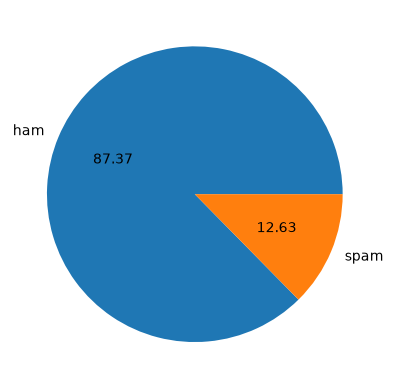

In [36]:
plt.pie(df['spam/ham'].value_counts(), labels =['ham','spam'],autopct='%0.2f')
plt.show()

In [37]:
# Data is imbalanced

In [38]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
ps = PorterStemmer()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kundanrathod1310/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kundanrathod1310/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kundanrathod1310/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
df['SMS_len']=df['SMS'].apply(len)

In [40]:
df['SMS_word']=df['SMS'].apply(lambda x:len(nltk.word_tokenize(x)))

In [41]:
df.head()

,spam/ham,SMS,SMS_len,SMS_word
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15


In [42]:
df['SMS_sent']=df['SMS'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [43]:
df[df['spam/ham'] == 'ham'][['SMS_len','SMS_word','SMS_sent']].describe()

,SMS_len,SMS_word,SMS_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [44]:
df[df['spam/ham'] == 'spam'][['SMS_len','SMS_word','SMS_sent']].describe()

,SMS_len,SMS_word,SMS_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='SMS_word', ylabel='Count'>

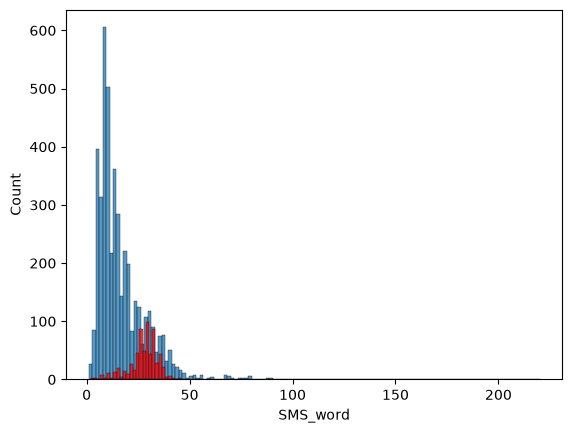

In [45]:
sns.histplot(df[df['spam/ham']=='ham']['SMS_word'])
sns.histplot(df[df['spam/ham']=='spam']['SMS_word'],color='red')

<Axes: xlabel='SMS_len', ylabel='Count'>

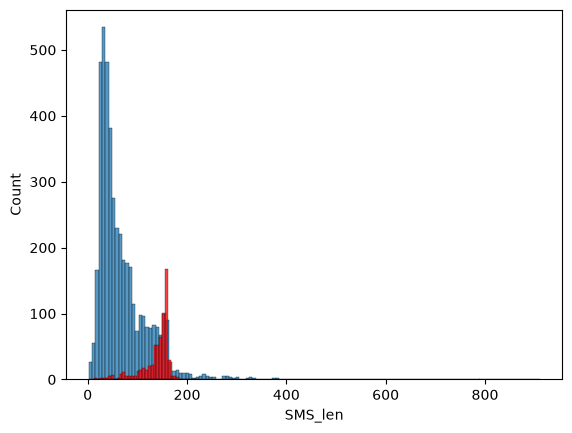

In [46]:
sns.histplot(df[df['spam/ham']=='ham']['SMS_len'])
sns.histplot(df[df['spam/ham']=='spam']['SMS_len'],color='red')

In [47]:
le = LabelEncoder()
df['spam/ham']=le.fit_transform(df['spam/ham'])

<Axes: >

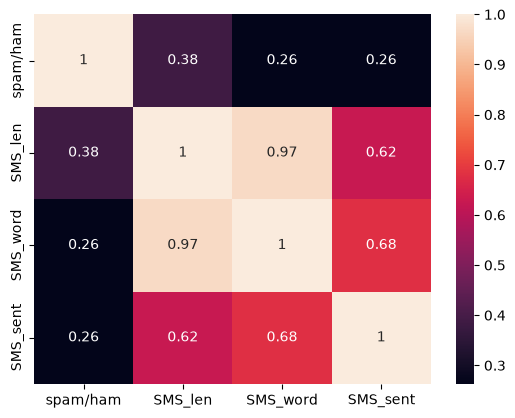

In [48]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

## DATA PREPROCESSING

In [49]:
def trans_SMS(SMS):
    SMS = SMS.lower()    # Covert SMS in Lower case
    SMS = nltk.word_tokenize(SMS)    # Create list of words in SMS
    new_sms = []    
    for i in SMS:
        if i.isalnum():    # Removing Special Characters
            new_sms.append(i)

    SMS = new_sms[:]
    new_sms.clear()
    for i in SMS:
        if i not in stopwords.words('english') and i not in string.punctuation:    # Removing punctuation and stopword
            new_sms.append(i)
    
    SMS = new_sms[:]
    new_sms.clear()
    for i in SMS:
        new_sms.append(ps.stem(i))

        
    return ' '.join(new_sms)

In [50]:
print(trans_SMS('I loved the YT lectures on Machine Learning. How about you?'))

love yt lectur machin learn


In [51]:
df['transformed_SMS']=df['SMS'].apply(trans_SMS)

In [52]:
df.head()

,spam/ham,SMS,SMS_len,SMS_word,SMS_sent,transformed_SMS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [55]:
from wordcloud import WordCloud
wc = WordCloud(width = 500 , height = 500 , min_font_size = 10 , background_color = 'white')

In [56]:
spam_wc = wc.generate(df[df['spam/ham'] == 1]['transformed_SMS'].str.cat(sep=' '))

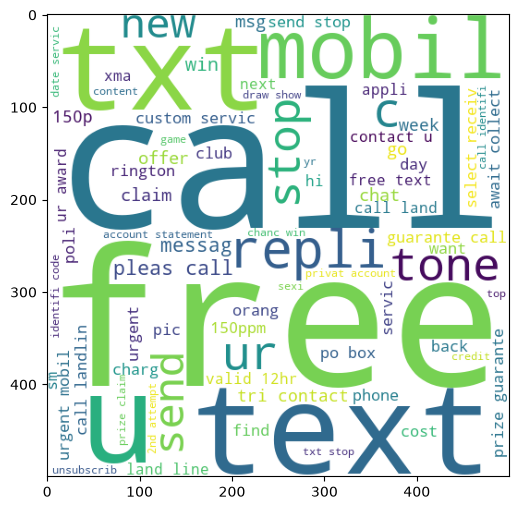

In [57]:
plt.figure(figsize=(20,6))
plt.imshow(spam_wc)

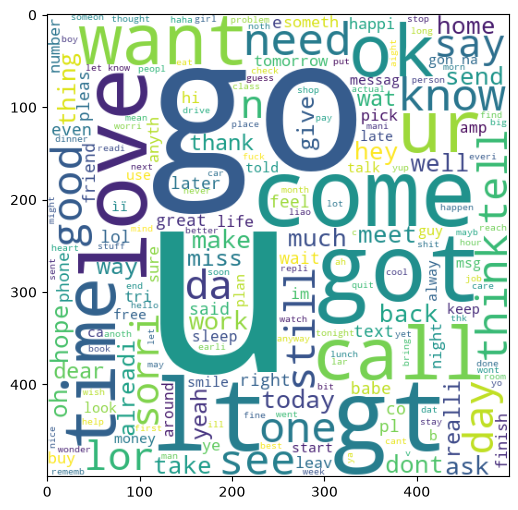

In [58]:
ham_wc = wc.generate(df[df['spam/ham'] == 0]['transformed_SMS'].str.cat(sep=' '))
plt.figure(figsize=(20,6))
plt.imshow(ham_wc)

In [59]:
spam_word = []
for msg in df[df['spam/ham']==1]['transformed_SMS'].tolist():
    for word in msg.split():
        spam_word.append(word)
        

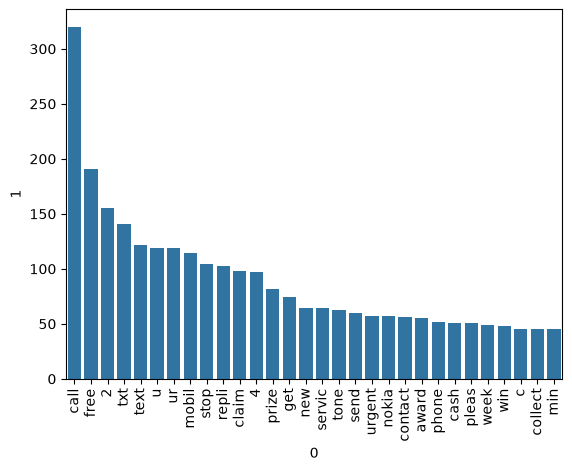

In [60]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_word).most_common(30))[0],y=pd.DataFrame(Counter(spam_word).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [61]:
ham_word = []
for msg in df[df['spam/ham']==0]['transformed_SMS'].tolist():
    for word in msg.split():
        ham_word.append(word)

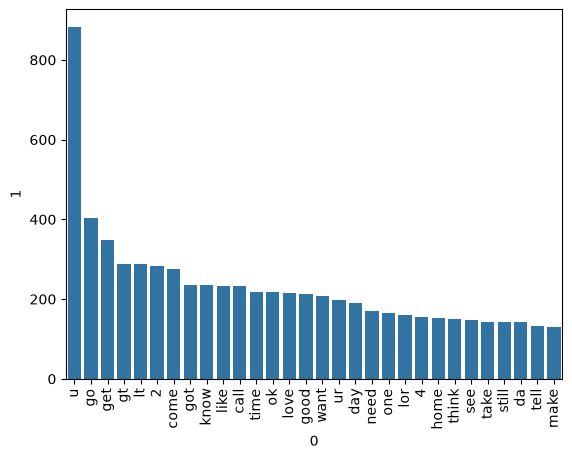

In [62]:
sns.barplot(x=pd.DataFrame(Counter(ham_word).most_common(30))[0],y=pd.DataFrame(Counter(ham_word).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

## MODEL TRAINING

In [63]:
X = df['transformed_SMS']

In [64]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [65]:
X = cv.fit_transform(X).toarray()

In [66]:
X.shape

(5169, 6708)

In [67]:
y = df['spam/ham']

In [68]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)
y_preb = gnb.predict(X_test)
print('Accuracy Score = ',accuracy_score(y_test,y_preb))
print('Precision Score = ',precision_score(y_test,y_preb))

Accuracy Score =  0.8684719535783365
Precision Score =  0.5185185185185185


In [70]:
mnb = MultinomialNB()
mnb.fit(X_train,y_train)
y_preb = mnb.predict(X_test)
print('Accuracy Score = ',accuracy_score(y_test,y_preb))
print('Precision Score = ',precision_score(y_test,y_preb))

Accuracy Score =  0.9738878143133463
Precision Score =  0.8881578947368421


In [71]:
bnb = BernoulliNB()
bnb.fit(X_train,y_train)
y_preb = bnb.predict(X_test)
print('Accuracy Score = ',accuracy_score(y_test,y_preb))
print('Precision Score = ',precision_score(y_test,y_preb))

Accuracy Score =  0.9661508704061895
Precision Score =  0.9661016949152542


In [72]:
import pickle
pickle.dump(cv,open('vectorizer.pkl','wb'))
pickle.dump(bnb,open('model.pkl','wb'))